In [1]:
import numpy as np

import pickle
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Dict

import os
import sys
parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
sys.path.append(parent_dir)


def build_reward_map_from_bouts(
    bouts,
    num_nodes: int = 127,
    exclude_first_n: int = 5,
):
    """
    Build reward_map[node] = average reward_anticipation_p at that node.

    Parameters
    ----------
    bouts : list of dict
        Loaded npz dicts (like in your plotting code)
    num_nodes : int
    exclude_first_n : int
        Ignore early steps (burn-in)

    Returns
    -------
    reward_map : np.ndarray (num_nodes,)
    counts     : np.ndarray (num_nodes,)
    """

    reward_sum = np.zeros(num_nodes, dtype=np.float64)
    counts = np.zeros(num_nodes, dtype=np.int64)

    for b in bouts:

        obs = np.asarray(b["obs_full"]).astype(int)
        rew_pred = np.asarray(b["reward_anticipation_p"])  # shape (T-1,)
        mask = np.asarray(b.get("mask", np.ones_like(rew_pred, bool))).astype(bool)

        L = min(len(rew_pred), len(obs) - 1)
        if L <= 0:
            continue

        nodes = obs[1:1+L]
        rew_pred = rew_pred[:L]
        mask = mask[:L]

        # exclude first steps (optional)
        valid_idx = np.arange(L) >= exclude_first_n

        valid = valid_idx & mask & np.isfinite(rew_pred)

        for node, val in zip(nodes[valid], rew_pred[valid]):
            reward_sum[node] += float(val)
            counts[node] += 1

    reward_map = np.zeros(num_nodes, dtype=np.float64)
    valid_nodes = counts > 0
    reward_map[valid_nodes] = reward_sum[valid_nodes] / counts[valid_nodes]

    return reward_map, counts




def build_value_map_from_bouts(
    bouts,
    num_nodes: int = 127,
    gamma: float = 0.95,
    n_iters: int = 100,
    tau=0.1,
):
    """
    Build value map purely from exploratory bouts:
      1) reward_map from reward_anticipation_p
      2) transition graph from observed transitions
      3) value propagation over that graph

    Returns
    -------
    value_map : (num_nodes,)
    reward_map : (num_nodes,)
    transition_graph : dict[node] -> set(next_nodes)
    """

    # --------------------------------------------------
    # 1) Build reward map
    # --------------------------------------------------
    reward_sum = np.zeros(num_nodes, dtype=np.float64)
    counts = np.zeros(num_nodes, dtype=np.int64)

    # --------------------------------------------------
    # 2) Build transition graph
    # --------------------------------------------------
    transition_graph = {i: set() for i in range(num_nodes)}

    for b in bouts:
        obs = np.asarray(b["obs_full"]).astype(int)
        rew_pred = np.asarray(b["reward_anticipation_p"])

        L = min(len(rew_pred), len(obs) - 1)
        if L <= 0:
            continue

        nodes_next = obs[1:1+L]
        nodes_prev = obs[:L]
        rew_pred = rew_pred[:L]

        # reward map
        for node, val in zip(nodes_next, rew_pred):
            reward_sum[node] += float(val)
            counts[node] += 1

        for u, v in zip(nodes_prev, nodes_next):
            transition_graph[int(u)].add(int(v))

    reward_map = np.zeros(num_nodes, dtype=np.float64)
    valid_nodes = counts > 0
    reward_map[valid_nodes] = reward_sum[valid_nodes] / counts[valid_nodes]

    # --------------------------------------------------
    # 3) Value propagation over learned graph
    # --------------------------------------------------
    value = reward_map.copy()

    for _ in range(n_iters):
        new_value = value.copy()

        for node in range(num_nodes):
            next_nodes = transition_graph[node]

            if len(next_nodes) == 0:
                continue
            
            vals = np.array([value[n] for n in next_nodes])
            soft = np.log(np.sum(np.exp(vals / tau))) * tau

            new_value[node] = reward_map[node] + gamma * soft

        value = new_value

    return value, reward_map, transition_graph

In [2]:
def load_bouts_from_dir(metrics_dir: Path):
    """Load all bout npz files in a dir and return list of dicts (with bout_id)."""
    files = sorted(metrics_dir.glob("bout_*_metrics.npz"))
    bouts = []
    for fp in files:
        d = np.load(fp, allow_pickle=True)
        bout = {k: d[k] for k in d.files}
        name = fp.name
        try:
            bid = int(name.split("bout_")[-1].split("_")[0])
        except Exception:
            bid = len(bouts) + 1
        bout["bout_id"] = int(bid)

        bouts.append(bout)
    return bouts

In [3]:
import numpy as np
import matplotlib.pyplot as plt


def compute_node_points_from_contents(content_path, min_points_per_node=1):
   
    node_points = {}
    with open(content_path, "rb") as f:
        content = pickle.load(f)
    num_bouts = len(content.ke)
    for bout_idx in range(num_bouts):
        ke_bout = np.asarray(content.ke[bout_idx])  # (T,2)
        no_bout = np.asarray(content.no[bout_idx])  # (K,2)
        if ke_bout.size == 0 or no_bout.size == 0:
            continue
        T = ke_bout.shape[0]
        node_per_frame = np.full(T, np.nan)
        for i, (node_id, start_frame) in enumerate(no_bout):
            start = int(start_frame)
            end = int(no_bout[i + 1, 1]) if i + 1 < len(no_bout) else T
            start = max(0, min(start, T))
            end   = max(start, min(end, T))
            node_per_frame[start:end] = int(node_id)
        valid = ~np.isnan(node_per_frame)
        if not np.any(valid):
            continue
        xs = ke_bout[valid, 0]
        ys = ke_bout[valid, 1]
        ns = node_per_frame[valid].astype(int)
        for x, y, n in zip(xs, ys, ns):
            d = node_points.setdefault(int(n), {"x": [], "y": [], "count": 0})
            d["x"].append(float(x))
            d["y"].append(float(y))
            d["count"] += 1

    node_points = {n: d for n, d in node_points.items() if d["count"] >= min_points_per_node}
    return node_points


import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, TwoSlopeNorm
from pathlib import Path


def plot_node_map(
    node_points: dict,
    node_values: np.ndarray,
    title: str = "",
    cmap: str = "viridis",
    point_size: int = 6,
    alpha: float = 0.9,
    max_points_per_node: int = 100,
    center_color: bool = False,
    color_bounds: tuple[float, float] | None = None,
    colorbar_label: str = "value",
    save_path: str | None = None,
    dpi: int = 600,
):
    """
    Plot a map over maze nodes with optionally fixed colorbar limits.

    Parameters
    ----------
    node_points : dict
        Output of compute_node_points_from_contents:
        {node_id: {"x": [...], "y": [...], "count": int}}

    node_values : np.ndarray, shape (num_nodes,)
        Values to plot, e.g. reward_map or value_map.

    title : str
        Figure title.

    cmap : str
        Matplotlib colormap name.

    point_size : int
        Scatter point size.

    alpha : float
        Scatter point transparency.

    max_points_per_node : int
        Maximum number of sampled points per node.

    center_color : bool
        If True, use a diverging normalization centered at 0.

    color_bounds : tuple[float, float] or None
        Fixed colorbar limits as (vmin, vmax).
        If None, limits are inferred from the plotted data.

    colorbar_label : str
        Label for the colorbar.

    save_path : str or None
        Optional path to save the figure, e.g. "plot.svg", "plot.pdf", "plot.png".

    dpi : int
        DPI used when saving rasterized layers.
    """

    all_x, all_y, all_c = [], [], []

    for node_id, pts in node_points.items():
        if node_id >= len(node_values):
            continue

        val = node_values[node_id]

        if not np.isfinite(val):
            continue

        xs = np.asarray(pts["x"], dtype=float)
        ys = np.asarray(pts["y"], dtype=float)

        if len(xs) == 0:
            continue

        if len(xs) > max_points_per_node:
            idx = np.random.choice(len(xs), max_points_per_node, replace=False)
            xs = xs[idx]
            ys = ys[idx]

        all_x.append(xs)
        all_y.append(ys)
        all_c.append(np.full(xs.shape, val, dtype=float))

    if len(all_x) == 0:
        print("Nothing to plot.")
        return None, None

    all_x = np.concatenate(all_x)
    all_y = np.concatenate(all_y)
    all_c = np.concatenate(all_c)

    # Fixed colorbar boundaries if provided
    if color_bounds is not None:
        vmin, vmax = color_bounds
    else:
        if center_color:
            abs_max = np.nanmax(np.abs(all_c))
            vmin, vmax = -abs_max, abs_max
        else:
            vmin = np.nanmin(all_c)
            vmax = np.nanmax(all_c)

    if not np.isfinite(vmin) or not np.isfinite(vmax):
        raise ValueError("Color bounds must be finite.")

    if vmin >= vmax:
        raise ValueError(f"Expected vmin < vmax, got color_bounds=({vmin}, {vmax}).")

    # Normalization
    if center_color:
        if not (vmin < 0 < vmax):
            raise ValueError(
                "center_color=True requires bounds that contain 0, "
                f"but got ({vmin}, {vmax})."
            )
        norm = TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)
    else:
        norm = Normalize(vmin=vmin, vmax=vmax)

    fig, ax = plt.subplots(figsize=(6, 6))

    sc = ax.scatter(
        all_x,
        all_y,
        c=all_c,
        s=point_size,
        cmap=cmap,
        norm=norm,
        alpha=alpha,
        linewidths=0,
        rasterized=True,
    )

    ax.invert_yaxis()
    ax.set_aspect("equal", "box")

    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")

    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label(colorbar_label)

    fig.tight_layout()

    if save_path is not None:
        suffix = Path(save_path).suffix.replace(".", "")
        fig.savefig(save_path, format=suffix, dpi=dpi, bbox_inches="tight")

    plt.show()

    return fig, ax

In [4]:
node_points = compute_node_points_from_contents(Path(f"../outdata/A1a-tf"))

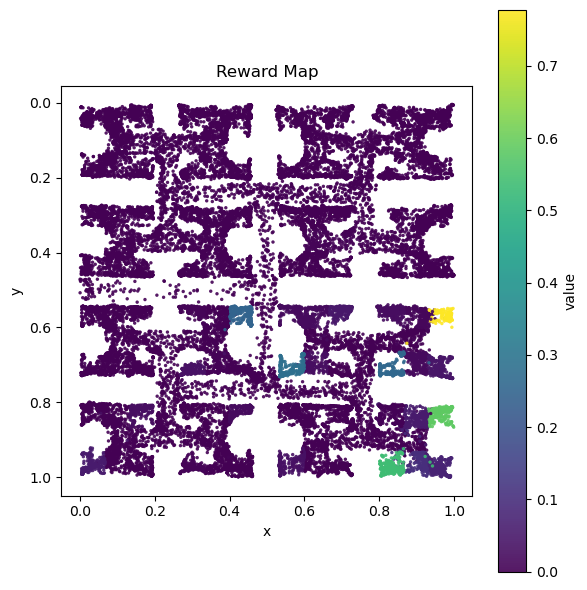

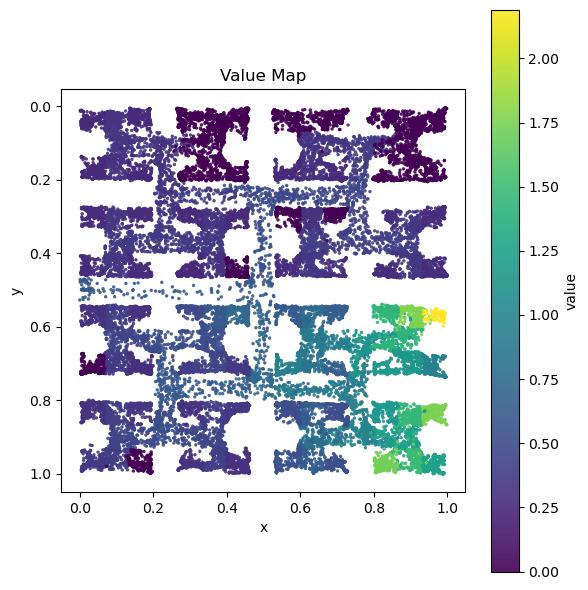

In [6]:
rew_p=0.1
seed=11
window_size=20
runs_folder = f"../REWARD_DRIVEN_1000/REWARD_DRIVEN_1000_runs_slurm_{window_size}_window_agent_rew_p_{rew_p}/{seed}"

# bouts are 00050, 00100, 00150, etc... 
for bout_num in ["00950"]:
    loaded = np.load(f"{runs_folder}/value_maps/value_map_bout_{bout_num}.npz")
    value_map = loaded["value_map"]
    reward_map = loaded["reward_map"]

    plot_node_map(node_points, reward_map, title="Reward Map", cmap="viridis", max_points_per_node=300, save_path=f"figs/reward_map_{rew_p}_{bout_num}.svg")
    plot_node_map(node_points, value_map, title="Value Map", cmap="viridis", max_points_per_node=300, save_path=f"figs/value_map_{rew_p}_{bout_num}.svg")

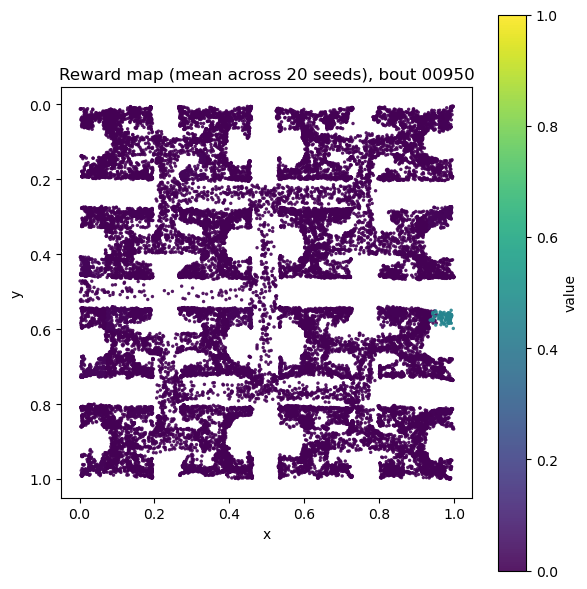

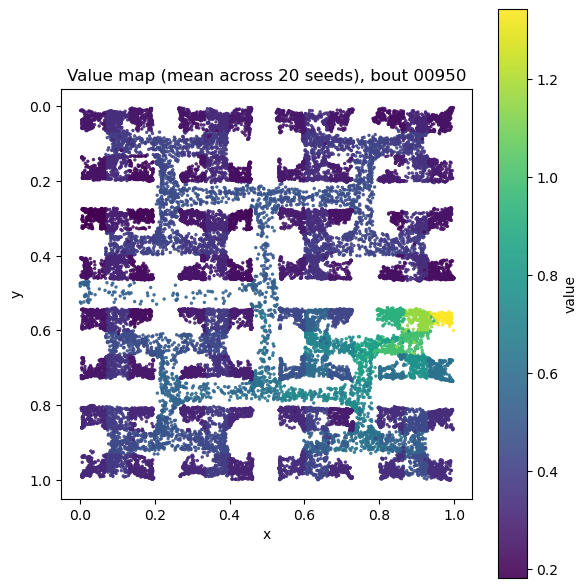

In [11]:
rew_p = 0.05
window_size = 20
seeds = range(20) 

base_runs_folder = Path(
    f"../REWARD_DRIVEN_1000/REWARD_DRIVEN_1000_runs_slurm_{window_size}_window_agent_rew_p_{rew_p}"
)

bout_nums = ["00950"]

for bout_num in bout_nums:
    reward_maps = []
    value_maps = []

    for seed in seeds:
        file_path = base_runs_folder / str(seed) / "value_maps" / f"value_map_bout_{bout_num}.npz"

        if not file_path.exists():
            print(f"Missing file for seed {seed}, bout {bout_num}: {file_path}")
            continue

        loaded = np.load(file_path)
        reward_maps.append(loaded["reward_map"])
        value_maps.append(loaded["value_map"])

    if len(reward_maps) == 0:
        print(f"No maps found for bout {bout_num}")
        continue

    # Stack: shape = (num_seeds, num_nodes)
    reward_maps = np.stack(reward_maps, axis=0)
    value_maps = np.stack(value_maps, axis=0)

    # Mean across seeds
    reward_map_mean = np.nanmean(reward_maps, axis=0)
    value_map_mean = np.nanmean(value_maps, axis=0)

    n_seeds_used = reward_maps.shape[0]

    plot_node_map(
        node_points,
        reward_map_mean,
        color_bounds=(0, 1),
        title=f"Reward map (mean across {n_seeds_used} seeds), bout {bout_num}",
        cmap="viridis",
        max_points_per_node=300,
        save_path=f"figs/reward_map_mean_rewp_{rew_p}_{bout_num}.svg",
    )

    plot_node_map(
        node_points,
        value_map_mean,
        # color_bounds=(0, 3),
        title=f"Value map (mean across {n_seeds_used} seeds), bout {bout_num}",
        cmap="viridis",
        max_points_per_node=300,
        save_path=f"figs/value_map_mean_rewp_{rew_p}_{bout_num}.svg",
    )

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


def plot_mean_predicted_reward_for_node(
    base_parent=Path("../REWARD_DRIVEN_1000"),
    window_size: int = 20,
    rew_ps=None,
    seeds=range(30),
    bout_num: str = "00950",
    node_id: int = 116,
    save_dir: str | Path = "figs",
    line_color: str = "#5B7FA6",
):
    """
    Plot mean predicted reward at one node across rew_p values.
    """

    if rew_ps is None:
        rew_ps = np.round(np.arange(0.0, 0.1001, 0.005), 3)

    rew_ps = np.asarray(rew_ps, dtype=float)
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    mean_vals = []
    std_vals = []
    n_seeds_used = []

    all_seed_vals_by_rewp = {}

    for rew_p in rew_ps:
        base_runs_folder = base_parent / (
            f"REWARD_DRIVEN_1000_runs_slurm_{window_size}_window_agent_rew_p_{rew_p}"
        )

        seed_vals = []

        for seed in seeds:
            file_path = (
                base_runs_folder
                / str(seed)
                / "value_maps"
                / f"value_map_bout_{bout_num}.npz"
            )

            if not file_path.exists():
                # print(f"Missing file for seed {seed}, rew_p={rew_p}: {file_path}")
                continue

            loaded = np.load(file_path)

            if "reward_map" not in loaded:
                continue

            reward_map = loaded["reward_map"]

            if node_id >= len(reward_map):
                continue

            val = reward_map[node_id]
            if np.isfinite(val):
                seed_vals.append(float(val))

        seed_vals = np.asarray(seed_vals, dtype=float)
        all_seed_vals_by_rewp[rew_p] = seed_vals
        n_seeds_used.append(len(seed_vals))

        if len(seed_vals) == 0:
            mean_vals.append(np.nan)
            std_vals.append(np.nan)
        else:
            mean_vals.append(np.mean(seed_vals))
            std_vals.append(np.std(seed_vals, ddof=1) if len(seed_vals) > 1 else 0.0)

        print(
            f"rew_p={rew_p:.3f} | "
            f"mean reward_map[{node_id}]={mean_vals[-1]} | "
            f"STD={std_vals[-1]} | "
            f"seeds used={n_seeds_used[-1]}"
        )

    mean_vals = np.asarray(mean_vals, dtype=float)
    std_vals = np.asarray(std_vals, dtype=float)
    n_seeds_used = np.asarray(n_seeds_used, dtype=int)

    # ------------------------------------------------------------
    # Plot
    fig, ax = plt.subplots(figsize=(7, 4))

    ax.errorbar(
        rew_ps,
        mean_vals,
        yerr=std_vals,
        marker="o",
        capsize=4,
        linewidth=2,
        color=line_color,
        ecolor=line_color,
        markerfacecolor="white",
        markeredgecolor=line_color,
        label="mean ± STD across seeds",
        zorder=3,
    )

    cmap = plt.cm.cividis
    colors = cmap(np.linspace(0.15, 0.9, len(rew_ps)))

    rng = np.random.default_rng(0)

    for i, rew_p in enumerate(rew_ps):
        vals = all_seed_vals_by_rewp.get(rew_p, np.array([]))

        if len(vals) == 0:
            continue

        jitter = rng.normal(0, 0.0007, size=len(vals))

        ax.scatter(
            np.full(len(vals), rew_p) + jitter,
            vals,
            color=colors[i],
            alpha=0.8,
            s=32,
            edgecolors="white",
            linewidths=0.5,
            zorder=2,
        )

    ax.set_xlabel("reward-driven probability, rew_p")
    ax.set_ylabel(f"Predicted reward at node {node_id}")
    ax.set_title(f"Mean predicted reward at node {node_id}, bout {bout_num}")
    ax.grid(True, alpha=0.25)
    ax.legend()

    fig.tight_layout()

    fig.savefig(
        save_dir / f"pred_reward_node_{node_id}_vs_rewp_bout_{bout_num}_window_{window_size}.svg",
        format="svg",
        bbox_inches="tight",
    )

    # fig.savefig(
    #     save_dir / f"pred_reward_node_{node_id}_vs_rewp_bout_{bout_num}_window_{window_size}.png",
    #     dpi=300,
    #     bbox_inches="tight",
    # )

    plt.show()

    return {
        "rew_ps": rew_ps,
        "mean_vals": mean_vals,
        "std_vals": std_vals,
        "n_seeds_used": n_seeds_used,
        "all_seed_vals_by_rewp": all_seed_vals_by_rewp,
    }

rew_p=0.000 | mean reward_map[116]=0.9055766509555271 | STD=0.1796261645984343 | seeds used=30
rew_p=0.005 | mean reward_map[116]=0.9533830634356174 | STD=0.18871946036347098 | seeds used=30
rew_p=0.010 | mean reward_map[116]=0.9651297855613753 | STD=0.18246400964068116 | seeds used=30
rew_p=0.015 | mean reward_map[116]=0.9604851416324769 | STD=0.15651501540736326 | seeds used=30
rew_p=0.020 | mean reward_map[116]=0.958335520038356 | STD=0.14918618178120935 | seeds used=30
rew_p=0.025 | mean reward_map[116]=0.8491929146472849 | STD=0.33629715625960466 | seeds used=30
rew_p=0.030 | mean reward_map[116]=0.8417515837804083 | STD=0.34941075494350315 | seeds used=30
rew_p=0.035 | mean reward_map[116]=0.7563866956540818 | STD=0.37422439905872623 | seeds used=30
rew_p=0.040 | mean reward_map[116]=0.7129512595374495 | STD=0.42248234594667383 | seeds used=30
rew_p=0.045 | mean reward_map[116]=0.6921273188604178 | STD=0.43101285251158256 | seeds used=30
rew_p=0.050 | mean reward_map[116]=0.40461

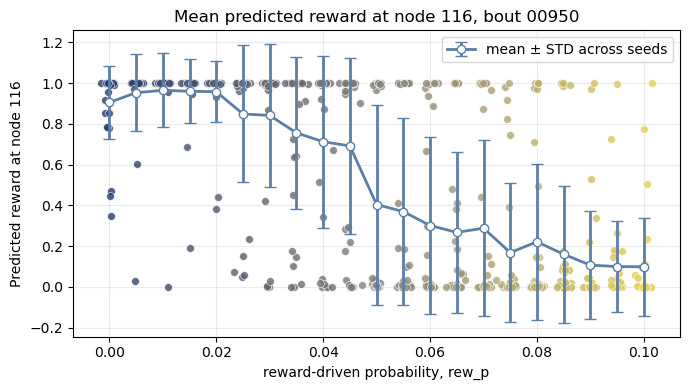

In [13]:
result = plot_mean_predicted_reward_for_node(
    base_parent=Path("../REWARD_DRIVEN_1000"),
    window_size=20,
    rew_ps=np.round(np.arange(0.0, 0.1001, 0.005), 3),
    seeds=range(30),
    bout_num="00950",
    node_id=116,
    save_dir="figs",
)

# Expected time to the reward

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

def load_selected_bouts(metrics_dir, start, end):
    bouts = []
    
    for bout_id in range(start, end + 1):
        pattern = f"bout_{bout_id:05d}_metrics.npz"
        fp = metrics_dir / pattern
        
        if not fp.exists():
            continue
        
        d = np.load(fp, allow_pickle=True)
        bout = {k: d[k] for k in d.files}
        bout["bout_id"] = bout_id
        bouts.append(bout)
    
    return bouts

# -------------------------
# Settings
# -------------------------
window_size = 20
reward_ps = ["0.0","0.005", "0.01", "0.015", "0.02", "0.025", "0.03", "0.035", "0.04", "0.045", "0.05","0.055", "0.06", "0.065", "0.07", "0.075", "0.08", "0.085", "0.09", "0.095", "0.1"]


seeds = range(30)

bout_start = 900
bout_end = 1000
 


def normalized_time_to_reward(bout, reward_node=116):
    obs = np.asarray(bout["obs_full"])
    bout_len = len(obs)
    
    hits = np.where(obs == reward_node)[0]
    
    if len(hits) > 0:
        return int(hits[0]) / bout_len
    
    return 1.0

def time_to_reward(bout, reward_node=116):
    obs = np.asarray(bout["obs_full"])
    horizon = len(obs)
    
    hits = np.where(obs == reward_node)[0]
    
    if len(hits) > 0:
        return int(hits[0])
    
    return horizon


rows = []

for rew_p in tqdm(reward_ps):
    for seed in seeds:
        metrics_dir = Path(
            f"../REWARD_DRIVEN_1000/REWARD_DRIVEN_1000_runs_slurm_{window_size}_window_agent_rew_p_{rew_p}/{seed}"
        )
        
        selected_bouts = load_selected_bouts(metrics_dir, bout_start, bout_end)
        
        times = [
            time_to_reward(b, reward_node=116)
            for b in selected_bouts
        ]
        
        rows.append({
            "reward_p": rew_p,
            "seed": seed,
            "mean_time_to_reward": np.mean(times) if len(times) > 0 else np.nan,
            "n_bouts": len(times),
        })


df_seed = pd.DataFrame(rows)
df_avg = (
    df_seed
    .groupby("reward_p", as_index=False)
    .agg(
        mean_time_to_reward=("mean_time_to_reward", "mean"),
        sem_time_to_reward=(
            "mean_time_to_reward",
            lambda x: x.std(ddof=1) / np.sqrt(x.notna().sum())
        ),
        n_seeds=("mean_time_to_reward", lambda x: x.notna().sum()),
        mean_n_bouts=("n_bouts", "mean"),
    )
)

df_avg["reward_p_float"] = df_avg["reward_p"].astype(float)
df_avg = df_avg.sort_values("reward_p_float")
df_avg


100%|██████████| 21/21 [04:04<00:00, 11.66s/it]


,reward_p,mean_time_to_reward,sem_time_to_reward,n_seeds,mean_n_bouts,reward_p_float
0,0.0,65.293729,0.608909,30,101.0,0.000
1,0.005,58.716502,0.550015,30,101.0,0.005
2,0.01,51.459076,0.767489,30,101.0,0.010
3,0.015,46.956106,0.881452,30,101.0,0.015
4,0.02,42.995380,0.991798,30,101.0,0.020
5,0.025,41.619142,1.926185,30,101.0,0.025
6,0.03,40.245875,2.082870,30,101.0,0.030
7,0.035,40.121782,2.368315,30,101.0,0.035
8,0.04,41.442244,3.215029,30,101.0,0.040
9,0.045,41.188779,3.283787,30,101.0,0.045


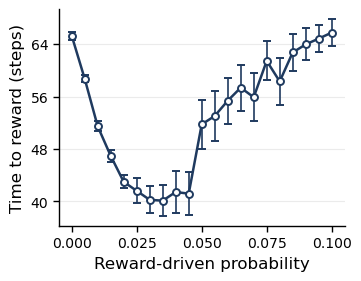

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

if not hasattr(mpl.rcParams, "_get"):
    mpl.rcParams._get = mpl.rcParams.get

color_spatial    = "#1F3A5F"
color_transition = "#006D6F"
color_arc        = "#8C3B0E"

mpl.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.linewidth": 1.0,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

fig, ax = plt.subplots(figsize=(3.5, 2.7), constrained_layout=True)

ax.errorbar(
    df_avg["reward_p_float"],
    df_avg["mean_time_to_reward"],
    yerr=df_avg["sem_time_to_reward"],
    marker="o",
    markersize=5,
    markerfacecolor="white",
    markeredgecolor=color_spatial,
    markeredgewidth=1.4,
    linestyle="-",
    linewidth=1.8,
    color=color_spatial,
    ecolor=color_spatial,
    elinewidth=1.2,
    capsize=3,
    capthick=1.2,
)

ax.set_xlabel("Reward-driven probability")
ax.set_ylabel("Time to reward (steps)")


ax.grid(True, axis="y", alpha=0.25, linewidth=0.8)
ax.grid(False, axis="x")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(direction="out")
ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
ax.xaxis.set_major_locator(MaxNLocator(nbins=5))


plt.show()

fig.savefig("figs/time_to_reward.svg")
# fig.savefig("time_to_reward.png", dpi=600, bbox_inches="tight")

## learning in time

In [44]:
# -------------------------
# Settings
# -------------------------
window_size = 20

reward_ps = [
    "0.0", "0.005", "0.01", "0.015", "0.02", "0.025",
    "0.03", "0.035", "0.04", "0.045", "0.05", "0.055",
    "0.06", "0.065", "0.07", "0.075", "0.08", "0.085",
    "0.09", "0.095", "0.1"
]

seeds = range(30)

# Windows: 0-50, 50-100, ..., 950-1000
bout_step = 50
bout_windows = [(start, start + bout_step) for start in range(0, 1000, bout_step)]

reward_node = 116


def normalized_time_to_reward(bout, reward_node=116):
    obs = np.asarray(bout["obs_full"])
    bout_len = len(obs)

    hits = np.where(obs == reward_node)[0]

    if len(hits) > 0:
        return int(hits[0]) / bout_len

    return 1.0


def time_to_reward(bout, reward_node=116):
    obs = np.asarray(bout["obs_full"])
    horizon = len(obs)

    hits = np.where(obs == reward_node)[0]

    if len(hits) > 0:
        return int(hits[0])

    return horizon


rows = []

for rew_p in tqdm(reward_ps, desc="reward_p"):
    for seed in seeds:
        metrics_dir = Path(
            f"../REWARD_DRIVEN_1000/"
            f"REWARD_DRIVEN_1000_runs_slurm_{window_size}_window_agent_rew_p_{rew_p}/"
            f"{seed}"
        )

        for bout_start, bout_end in bout_windows:
            selected_bouts = load_selected_bouts(metrics_dir, bout_start, bout_end)

            times = [
                time_to_reward(b, reward_node=reward_node)
                for b in selected_bouts
            ]

            rows.append({
                "reward_p": rew_p,
                "reward_p_float": float(rew_p),
                "seed": seed,
                "bout_start": bout_start,
                "bout_end": bout_end,
                "bout_window": f"{bout_start}-{bout_end}",
                "mean_time_to_reward": np.mean(times) if len(times) > 0 else np.nan,
                "n_bouts": len(times),
            })


df_seed_by_bout = pd.DataFrame(rows)

df_avg_by_bout = (
    df_seed_by_bout
    .groupby(["reward_p", "reward_p_float", "bout_start", "bout_end", "bout_window"], as_index=False)
    .agg(
        mean_time_to_reward=("mean_time_to_reward", "mean"),
        sem_time_to_reward=(
            "mean_time_to_reward",
            lambda x: x.std(ddof=1) / np.sqrt(x.notna().sum())
        ),
        n_seeds=("mean_time_to_reward", lambda x: x.notna().sum()),
        mean_n_bouts=("n_bouts", "mean"),
    )
    .sort_values(["bout_start", "reward_p_float"])
)

df_avg_by_bout

reward_p: 100%|██████████| 21/21 [37:00<00:00, 105.74s/it]


,reward_p,reward_p_float,bout_start,bout_end,bout_window,mean_time_to_reward,sem_time_to_reward,n_seeds,mean_n_bouts
0,0.0,0.000,0,50,0-50,65.772667,0.500492,30,50.0
20,0.005,0.005,0,50,0-50,65.407333,0.408633,30,50.0
40,0.01,0.010,0,50,0-50,65.563333,0.541055,30,50.0
60,0.015,0.015,0,50,0-50,67.080667,0.434702,30,50.0
80,0.02,0.020,0,50,0-50,67.296000,0.474932,30,50.0
...,...,...,...,...,...,...,...,...,...
339,0.08,0.080,950,1000,950-1000,57.826797,3.821225,30,51.0
359,0.085,0.085,950,1000,950-1000,62.392157,2.910360,30,51.0
379,0.09,0.090,950,1000,950-1000,64.098693,2.335352,30,51.0
399,0.095,0.095,950,1000,950-1000,63.277124,2.497533,30,51.0


In [47]:
df_seed_by_bout.to_pickle("metrics_agent/time_to_reward_by_seed_by_bout.pkl")
df_avg_by_bout.to_pickle("metrics_agent/time_to_reward_avg_by_bout.pkl")

In [ ]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.ticker import MaxNLocator
from pathlib import Path
from mpl_toolkits.axes_grid1 import make_axes_locatable


def plot_metric_by_bout(
    df_avg_ce_by_bout,
    cmap="viridis",
    figsize=(4.8, 3.2),
    show_sem=False,
    linewidth=1.8,
    alpha_line=0.95,
    alpha_band=0.10,
    marker=None,
    markersize=3.0,
    tick_every=4,
    column_name ="mean_time_to_reward", # or  "mean_transition_balanced_ce_p"
    column_sem_name = "sem_transition_balanced_ce_p", # or sem_time_to_reward
    xlabel="Training bout",
    ylabel=r"Transition-balanced $CE_p$",
    colorbar_label="Reward-driven probability",
    title=None,
    save_path=None,
    dpi=600,
):
    

    required_cols = {
        "reward_p",
        "reward_p_float",
        "bout_start",
        "bout_end",
        column_name,
        column_sem_name
    }

    missing = required_cols - set(df_avg_ce_by_bout.columns)
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    mpl.rcParams.update({
        "font.size": 9,
        "axes.labelsize": 10,
        "axes.titlesize": 10,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "axes.linewidth": 0.9,
        "xtick.major.width": 0.9,
        "ytick.major.width": 0.9,
        "xtick.major.size": 3.5,
        "ytick.major.size": 3.5,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",
    })

    df = df_avg_ce_by_bout.copy()
    df = df.sort_values(["reward_p_float", "bout_start"]).reset_index(drop=True)

    window_df = (
        df[["bout_start", "bout_end"]]
        .drop_duplicates()
        .sort_values(["bout_start", "bout_end"])
        .reset_index(drop=True)
    )

    x = np.arange(len(window_df))
    xlabels = [
        f"{int(s)}–{int(e)}"
        for s, e in zip(window_df["bout_start"], window_df["bout_end"])
    ]

    rew_ps = np.sort(df["reward_p_float"].unique())

    norm = Normalize(vmin=np.min(rew_ps), vmax=np.max(rew_ps))
    cmap_obj = plt.get_cmap(cmap)

    fig, ax = plt.subplots(figsize=figsize)

    for rew_p in rew_ps:
        sub = (
            df[df["reward_p_float"] == rew_p]
            .sort_values("bout_start")
            .reset_index(drop=True)
        )

        merged = window_df.merge(
            sub,
            on=["bout_start", "bout_end"],
            how="left",
        )

        y = merged[column_name].to_numpy(dtype=float)
        sem = merged[column_sem_name].to_numpy(dtype=float)
        color = cmap_obj(norm(rew_p))

        ax.plot(
            x,
            y,
            color=color,
            linewidth=linewidth,
            alpha=alpha_line,
            marker=marker,
            markersize=markersize,
            solid_capstyle="round",
            solid_joinstyle="round",
            zorder=3,
        )

        if show_sem:
            ax.fill_between(
                x,
                y - sem,
                y + sem,
                color=color,
                alpha=alpha_band,
                linewidth=0,
                zorder=2,
            )

    ax.set_xlabel(xlabel, labelpad=6)
    ax.set_ylabel(ylabel, labelpad=6)

    if title is not None:
        ax.set_title(title, pad=8)

    # Clean axis styling
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.grid(True, axis="y", alpha=0.22, linewidth=0.7)
    ax.grid(False, axis="x")
    ax.set_axisbelow(True)

    ax.tick_params(axis="both", direction="out")

    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

    # X ticks
    tick_idx = np.arange(0, len(x), tick_every)
    if len(tick_idx) == 0 or tick_idx[-1] != len(x) - 1:
        tick_idx = np.append(tick_idx, len(x) - 1)

    ax.set_xticks(tick_idx)
    ax.set_xticklabels(
        [xlabels[i] for i in tick_idx],
        rotation=35,
        ha="right",
        rotation_mode="anchor",
    )

    # Avoid clipping endpoint lines
    ax.margins(x=0.02, y=0.06)

    # Compact colorbar matched to axis height
    sm = ScalarMappable(norm=norm, cmap=cmap_obj)
    sm.set_array([])

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="3.5%", pad=0.08)

    cbar = fig.colorbar(sm, cax=cax)
    cbar.set_label(colorbar_label, labelpad=8)
    cbar.ax.tick_params(labelsize=8, width=0.8, length=3)
    cbar.outline.set_linewidth(0.8)

    fig.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)

        suffix = save_path.suffix.replace(".", "")
        fig.savefig(save_path, format=suffix, dpi=dpi, bbox_inches="tight")

        # Also save PNG companion if saving vector
        if suffix in {"pdf", "svg"}:
            fig.savefig(save_path.with_suffix(".png"), dpi=dpi, bbox_inches="tight")

    plt.show()

    return fig, ax

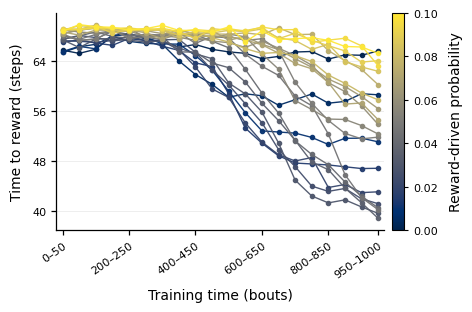

(<Figure size 480x320 with 2 Axes>,
 <Axes: xlabel='Training time (bouts)', ylabel='Time to reward (steps)'>)

In [91]:
df_avg_rew_time_by_bout = pd.read_pickle("metrics_agent/time_to_reward_avg_by_bout.pkl")


plot_metric_by_bout(
    df_avg_rew_time_by_bout,
    cmap="cividis",
    show_sem=False,
    marker='o',
    linewidth=1,
    tick_every=4,
    column_name="mean_time_to_reward",
    column_sem_name="sem_time_to_reward",
    xlabel="Training time (bouts)",
    ylabel="Time to reward (steps)",
    colorbar_label="Reward-driven probability",
    save_path="figs/rew_time_by_bout.svg",
)

# CE

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

def load_selected_bouts(metrics_dir, start, end):
    bouts = []
    
    for bout_id in range(start, end + 1):
        fp = metrics_dir / f"bout_{bout_id:05d}_metrics.npz"
        
        if not fp.exists():
            continue
        
        with np.load(fp, allow_pickle=True) as d:
            bout = {k: d[k] for k in d.files}
        
        bout["bout_id"] = bout_id
        bouts.append(bout)
    
    return bouts



def transition_balanced_mean_ce_p(bout):
    ce_p = np.asarray(bout["ce_p"])
    obs = np.asarray(bout["obs_full"]).astype(int)
    act = np.asarray(bout["act_full"]).astype(int)

    L = min(len(ce_p), len(obs) - 1, len(act) - 1)

    current = obs[:L]
    action = act[1:1+L]   # action that caused obs[t] -> obs[t+1]

    pair_means = []

    for s in np.unique(current):
        for a in np.unique(action[current == s]):
            mask = (current == s) & (action == a)
            if mask.any():
                pair_means.append(np.mean(ce_p[:L][mask]))

    return np.mean(pair_means) if len(pair_means) else np.nan

# -------------------------
# Settings
# -------------------------
window_size = 20


reward_ps = ["0.0","0.005", "0.01", "0.015", "0.02", "0.025", "0.03", "0.035", "0.04", "0.045", "0.05","0.055", "0.06", "0.065", "0.07", "0.075", "0.08", "0.085", "0.09", "0.095", "0.1"]

seeds = range(30)

bout_start = 900
bout_end = 1000
 

rows = []

for rew_p in tqdm(reward_ps, desc="reward_p"):
    for seed in seeds:
        metrics_dir = Path(
            f"../REWARD_DRIVEN_1000/REWARD_DRIVEN_1000_runs_slurm_{window_size}_window_agent_rew_p_{rew_p}/{seed}"
        )
        
        selected_bouts = load_selected_bouts(metrics_dir, bout_start, bout_end)
        
        ce_vals = [
            transition_balanced_mean_ce_p(b)
            for b in selected_bouts
        ]
        
        rows.append({
            "reward_p": rew_p,
            "seed": seed,
            "mean_node_balanced_ce_p": np.nanmean(ce_vals) if len(ce_vals) > 0 else np.nan,
            "n_bouts": len(ce_vals),
        })


df_seed_ce = pd.DataFrame(rows)

df_avg_ce = (
    df_seed_ce
    .groupby("reward_p", as_index=False)
    .agg(
        mean_node_balanced_ce_p=("mean_node_balanced_ce_p", "mean"),
        sem_node_balanced_ce_p=(
            "mean_node_balanced_ce_p",
            lambda x: x.std(ddof=1) / np.sqrt(x.notna().sum())
        ),
        n_seeds=("mean_node_balanced_ce_p", lambda x: x.notna().sum()),
        mean_n_bouts=("n_bouts", "mean"),
    )
)

df_avg_ce["reward_p_float"] = df_avg_ce["reward_p"].astype(float)
df_avg_ce = df_avg_ce.sort_values("reward_p_float")

df_avg_ce

reward_p: 100%|██████████| 21/21 [04:16<00:00, 12.20s/it]


,reward_p,mean_node_balanced_ce_p,sem_node_balanced_ce_p,n_seeds,mean_n_bouts,reward_p_float
0,0.0,0.873754,0.101277,30,101.0,0.000
1,0.005,0.653855,0.063340,30,101.0,0.005
2,0.01,0.670843,0.070041,30,101.0,0.010
3,0.015,1.060968,0.100549,30,101.0,0.015
4,0.02,1.431939,0.095395,30,101.0,0.020
5,0.025,1.695368,0.108643,30,101.0,0.025
6,0.03,1.832810,0.113528,30,101.0,0.030
7,0.035,1.812198,0.106058,30,101.0,0.035
8,0.04,1.841278,0.112258,30,101.0,0.040
9,0.045,2.044355,0.104949,30,101.0,0.045


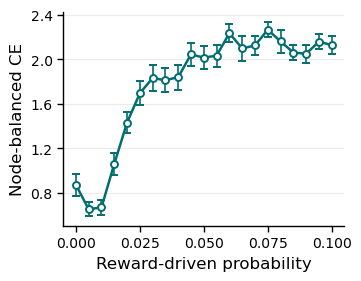

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

if not hasattr(mpl.rcParams, "_get"):
    mpl.rcParams._get = mpl.rcParams.get

color_spatial    = "#1F3A5F"
color_transition = "#006D6F"
color_arc        = "#8C3B0E"

mpl.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.linewidth": 1.0,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

fig, ax = plt.subplots(figsize=(3.5, 2.7), constrained_layout=True)

ax.errorbar(
    df_avg_ce["reward_p_float"],
    df_avg_ce["mean_node_balanced_ce_p"],
    yerr=df_avg_ce["sem_node_balanced_ce_p"],
    marker="o",
    markersize=5,
    markerfacecolor="white",
    markeredgecolor=color_transition,
    markeredgewidth=1.4,
    linestyle="-",
    linewidth=1.8,
    color=color_transition,
    ecolor=color_transition,
    elinewidth=1.2,
    capsize=3,
    capthick=1.2,
)

ax.set_xlabel("Reward-driven probability")
ax.set_ylabel(r"Node-balanced CE")
ax.grid(True, axis="y", alpha=0.25, linewidth=0.8)
ax.grid(False, axis="x")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(direction="out")
ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
ax.xaxis.set_major_locator(MaxNLocator(nbins=5))

plt.show()

fig.savefig("node_balanced_ce_p.svg")

# learning in time

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm


def load_selected_bouts(metrics_dir, start, end):
    bouts = []

    # end is exclusive, so 0-50 means bout_00000 ... bout_00049
    for bout_id in range(start, end):
        fp = metrics_dir / f"bout_{bout_id:05d}_metrics.npz"

        if not fp.exists():
            continue

        with np.load(fp, allow_pickle=True) as d:
            bout = {k: d[k] for k in d.files}

        bout["bout_id"] = bout_id
        bouts.append(bout)

    return bouts


def transition_balanced_mean_ce_p(bout):
    ce_p = np.asarray(bout["ce_p"])
    obs = np.asarray(bout["obs_full"]).astype(int)
    act = np.asarray(bout["act_full"]).astype(int)

    L = min(len(ce_p), len(obs) - 1, len(act) - 1)

    current = obs[:L]
    action = act[1:1 + L]   # action that caused obs[t] -> obs[t+1]

    pair_means = []

    for s in np.unique(current):
        for a in np.unique(action[current == s]):
            mask = (current == s) & (action == a)
            if mask.any():
                pair_means.append(np.mean(ce_p[:L][mask]))

    return np.mean(pair_means) if len(pair_means) else np.nan


# -------------------------
# Settings
# -------------------------
window_size = 20

reward_ps = [
    "0.0", "0.005", "0.01", "0.015", "0.02", "0.025",
    "0.03", "0.035", "0.04", "0.045", "0.05", "0.055",
    "0.06", "0.065", "0.07", "0.075", "0.08", "0.085",
    "0.09", "0.095", "0.1"
]

seeds = range(30)

# Windows: 0-50, 50-100, ..., 950-1000
bout_step = 50
bout_windows = [(start, start + bout_step) for start in range(0, 1000, bout_step)]


# -------------------------
# Compute metric by bout window
# -------------------------
rows = []

for rew_p in tqdm(reward_ps, desc="reward_p"):
    for seed in seeds:
        metrics_dir = Path(
            f"../REWARD_DRIVEN_1000/"
            f"REWARD_DRIVEN_1000_runs_slurm_{window_size}_window_agent_rew_p_{rew_p}/"
            f"{seed}"
        )

        for bout_start, bout_end in bout_windows:
            selected_bouts = load_selected_bouts(metrics_dir, bout_start, bout_end)

            ce_vals = [
                transition_balanced_mean_ce_p(b)
                for b in selected_bouts
            ]

            rows.append({
                "reward_p": rew_p,
                "reward_p_float": float(rew_p),
                "seed": seed,
                "bout_start": bout_start,
                "bout_end": bout_end,
                "bout_window": f"{bout_start}-{bout_end}",
                "mean_transition_balanced_ce_p": (
                    np.nanmean(ce_vals) if len(ce_vals) > 0 else np.nan
                ),
                "n_bouts": len(ce_vals),
            })


df_seed_ce_by_bout = pd.DataFrame(rows)

df_avg_ce_by_bout = (
    df_seed_ce_by_bout
    .groupby(
        ["reward_p", "reward_p_float", "bout_start", "bout_end", "bout_window"],
        as_index=False
    )
    .agg(
        mean_transition_balanced_ce_p=("mean_transition_balanced_ce_p", "mean"),
        sem_transition_balanced_ce_p=(
            "mean_transition_balanced_ce_p",
            lambda x: x.std(ddof=1) / np.sqrt(x.notna().sum())
        ),
        n_seeds=("mean_transition_balanced_ce_p", lambda x: x.notna().sum()),
        mean_n_bouts=("n_bouts", "mean"),
    )
    .sort_values(["bout_start", "reward_p_float"])
)

df_avg_ce_by_bout

reward_p: 100%|██████████| 21/21 [42:00<00:00, 120.05s/it]


,reward_p,reward_p_float,bout_start,bout_end,bout_window,mean_transition_balanced_ce_p,sem_transition_balanced_ce_p,n_seeds,mean_n_bouts
0,0.0,0.000,0,50,0-50,4.780043,0.005709,30,49.0
20,0.005,0.005,0,50,0-50,4.752854,0.006013,30,49.0
40,0.01,0.010,0,50,0-50,4.699769,0.010514,30,49.0
60,0.015,0.015,0,50,0-50,4.659236,0.015659,30,49.0
80,0.02,0.020,0,50,0-50,4.616844,0.018422,30,49.0
...,...,...,...,...,...,...,...,...,...
339,0.08,0.080,950,1000,950-1000,2.126298,0.114893,30,50.0
359,0.085,0.085,950,1000,950-1000,2.070959,0.079388,30,50.0
379,0.09,0.090,950,1000,950-1000,1.993982,0.086973,30,50.0
399,0.095,0.095,950,1000,950-1000,2.223730,0.070863,30,50.0


In [49]:
df_seed_ce_by_bout.to_pickle("metrics_agent/transition_balanced_ce_p_by_seed_by_bout.pkl")
df_avg_ce_by_bout.to_pickle("metrics_agent/transition_balanced_ce_p_avg_by_bout.pkl")

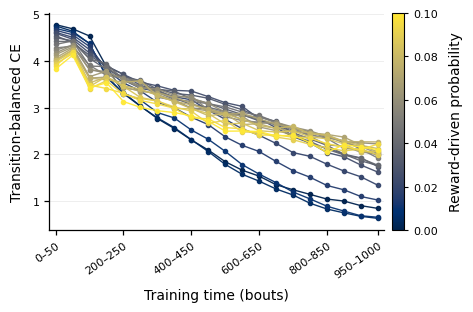

(<Figure size 480x320 with 2 Axes>,
 <Axes: xlabel='Training time (bouts)', ylabel='Transition-balanced CE'>)

In [90]:
df_avg_ce_p_by_bout = pd.read_pickle("metrics_agent/transition_balanced_ce_p_avg_by_bout.pkl")

plot_metric_by_bout(
    df_avg_ce_p_by_bout,
    cmap="cividis",
    show_sem=False,
    marker="o",
    linewidth=1,
    tick_every=4,
    column_name="mean_transition_balanced_ce_p",
    column_sem_name="sem_transition_balanced_ce_p",
    xlabel="Training time (bouts)",
    ylabel="Transition-balanced CE",
    colorbar_label="Reward-driven probability",
    save_path="figs/ce_p_by_bout.svg",
)